# LAB 7: PHÂN TÍCH DỮ LIỆU DẠNG VĂN BẢN VỚI NLTK

**Nội dung:**
1. Giới thiệu về thư viện NLTK
2. Tìm 1 từ với NLTK
3. Phân tích tần số của các từ
4. Lựa chọn các từ trong văn bản
5. Bigrams và Collocations
6. Sử dụng văn bản trên mạng
7. Rút trích văn bản từ trang HTML
8. Phân tích cảm xúc người dùng
9. Bài tập áp dụng

---
## Bước 0 – Cài đặt thư viện & Download dữ liệu NLTK

In [3]:
# Cài đặt thư viện cần thiết
!pip install nltk beautifulsoup4 lxml -q

In [4]:
import nltk
import string
import random
import warnings
warnings.filterwarnings('ignore')

# Download tất cả các gói NLTK cần thiết cho Lab 7
packages = [
    'gutenberg', 'stopwords', 'punkt', 'punkt_tab',
    'movie_reviews', 'wordnet', 'averaged_perceptron_tagger',
    'tagsets', 'names', 'omw-1.4', 'vader_lexicon'
]
for pkg in packages:
    nltk.download(pkg, quiet=True)

print('Download tất cả gói NLTK thành công!')

Download tất cả gói NLTK thành công!


---
## Phần 1 – Giới thiệu về thư viện NLTK

In [7]:
# Xem danh sách tất cả corpus có trong NLTK
gb = nltk.corpus.gutenberg
print('DANH SÁCH FILE TRONG GUTENBERG CORPUS')
for f in gb.fileids():
    print(f'  {f}')

DANH SÁCH FILE TRONG GUTENBERG CORPUS
  austen-emma.txt
  austen-persuasion.txt
  austen-sense.txt
  bible-kjv.txt
  blake-poems.txt
  bryant-stories.txt
  burgess-busterbrown.txt
  carroll-alice.txt
  chesterton-ball.txt
  chesterton-brown.txt
  chesterton-thursday.txt
  edgeworth-parents.txt
  melville-moby_dick.txt
  milton-paradise.txt
  shakespeare-caesar.txt
  shakespeare-hamlet.txt
  shakespeare-macbeth.txt
  whitman-leaves.txt


In [8]:
# Chọn văn bản Macbeth của Shakespeare
macbeth = nltk.corpus.gutenberg.words('shakespeare-macbeth.txt')

print(f'Tổng số từ trong Macbeth: {len(macbeth):,}')
print(f'\n10 từ đầu tiên: {list(macbeth[:10])}')

Tổng số từ trong Macbeth: 23,140

10 từ đầu tiên: ['[', 'The', 'Tragedie', 'of', 'Macbeth', 'by', 'William', 'Shakespeare', '1603', ']']


In [10]:
# Xem 5 câu đầu tiên
macbeth_sents = nltk.corpus.gutenberg.sents('shakespeare-macbeth.txt')
print('5 CÂU ĐẦU TIÊN')
for i, sent in enumerate(macbeth_sents[:5]):
    print(f'  Câu {i+1}: {sent}')

5 CÂU ĐẦU TIÊN
  Câu 1: ['[', 'The', 'Tragedie', 'of', 'Macbeth', 'by', 'William', 'Shakespeare', '1603', ']']
  Câu 2: ['Actus', 'Primus', '.']
  Câu 3: ['Scoena', 'Prima', '.']
  Câu 4: ['Thunder', 'and', 'Lightning', '.']
  Câu 5: ['Enter', 'three', 'Witches', '.']


---
## Phần 2 – Tìm 1 từ với NLTK

In [12]:
text = nltk.Text(macbeth)

# Tìm từ 'Stage' trong ngữ cảnh (concordance)
print('TÌM TỪ "Stage" TRONG VĂN BẢN')
text.concordance('Stage')

TÌM TỪ "Stage" TRONG VĂN BẢN
Displaying 3 of 3 matches:
nts with Dishes and Seruice ouer the Stage . Then enter Macbeth Macb . If it we
with mans Act , Threatens his bloody Stage : byth ' Clock ' tis Day , And yet d
 struts and frets his houre vpon the Stage , And then is heard no more . It is 


In [13]:
# Tìm ngữ cảnh chung của từ 'Stage'
print('NGỮ CẢNH CHUNG CỦA TỪ "Stage"')
text.common_contexts(['Stage'])

NGỮ CẢNH CHUNG CỦA TỪ "Stage"
the_. bloody_: the_,


In [14]:
# Tìm các từ tương tự với 'Stage'
print('CÁC TỪ TƯƠNG TỰ VỚI "Stage"')
text.similar('Stage')

CÁC TỪ TƯƠNG TỰ VỚI "Stage"
day time face warre ayre king bleeding man reuolt serieant like
knowledge broyle shew head spring heeles hare thane skie


---
## Phần 3 – Phân tích tần số của các từ

In [15]:
import matplotlib.pyplot as plt

# Tần số 10 từ phổ biến nhất (chưa lọc)
fd = nltk.FreqDist(macbeth)
print('10 TỪ PHỔ BIẾN NHẤT (chưa lọc)')
print(fd.most_common(10))

10 TỪ PHỔ BIẾN NHẤT (chưa lọc)
[(',', 1962), ('.', 1235), ("'", 637), ('the', 531), (':', 477), ('and', 376), ('I', 333), ('of', 315), ('to', 311), ('?', 241)]


In [16]:
# Xem stopwords tiếng Anh
sw = set(nltk.corpus.stopwords.words('english'))
print(f'Số lượng stopwords tiếng Anh: {len(sw)}')
print(f'Ví dụ 10 stopwords: {list(sw)[:10]}')

Số lượng stopwords tiếng Anh: 198
Ví dụ 10 stopwords: ['against', "don't", 'same', 'its', 'am', 'how', 'off', "couldn't", "weren't", 'mustn']


In [17]:
# Lọc stopwords
macbeth_filtered = [w for w in macbeth if w.lower() not in sw]
print(f'Số từ sau khi lọc stopwords: {len(macbeth_filtered):,}')

fd_filtered = nltk.FreqDist(macbeth_filtered)
print('\n=== 10 TỪ PHỔ BIẾN NHẤT (sau lọc stopwords) ===')
print(fd_filtered.most_common(10))

Số từ sau khi lọc stopwords: 14,946

=== 10 TỪ PHỔ BIẾN NHẤT (sau lọc stopwords) ===
[(',', 1962), ('.', 1235), ("'", 637), (':', 477), ('?', 241), ('Macb', 137), ('haue', 117), ('-', 100), ('Enter', 80), ('thou', 63)]


In [18]:
# Lọc thêm dấu câu
punctuation = set(string.punctuation)
macbeth_filtered2 = [
    w.lower() for w in macbeth
    if w.lower() not in sw and w.lower() not in punctuation
]
print(f'Số từ sau khi lọc stopwords + dấu câu: {len(macbeth_filtered2):,}')

fd2 = nltk.FreqDist(macbeth_filtered2)
print('\n10 TỪ PHỔ BIẾN NHẤT (sau lọc stopwords + dấu câu)')
print(fd2.most_common(10))

Số từ sau khi lọc stopwords + dấu câu: 10,157

10 TỪ PHỔ BIẾN NHẤT (sau lọc stopwords + dấu câu)
[('macb', 137), ('haue', 122), ('thou', 90), ('enter', 81), ('shall', 68), ('macbeth', 62), ('vpon', 62), ('thee', 61), ('macd', 58), ('vs', 57)]


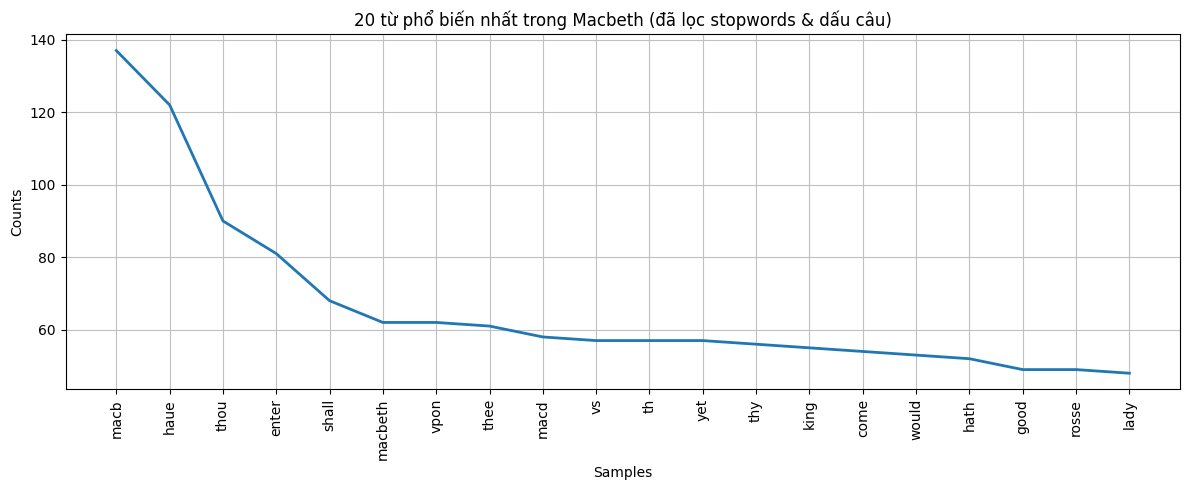

In [19]:
# Biểu đồ tần số 20 từ phổ biến nhất
plt.figure(figsize=(12, 5))
fd2.plot(20, title='20 từ phổ biến nhất trong Macbeth (đã lọc stopwords & dấu câu)',
         cumulative=False)
plt.tight_layout()
plt.show()

---
## Phần 4 – Lựa chọn các từ trong văn bản

In [20]:
# Rút trích các từ có độ dài > 12 ký tự
long_words = [w for w in macbeth if len(w) > 12]
print('CÁC TỪ CÓ ĐỘ DÀI > 12 KÝ TỰ')
print(sorted(long_words))

CÁC TỪ CÓ ĐỘ DÀI > 12 KÝ TỰ
['Assassination', 'Chamberlaines', 'Distinguishes', 'Gallowgrosses', 'Metaphysicall', 'Northumberland', 'Voluptuousnesse', 'commendations', 'multitudinous', 'supernaturall', 'vnaccompanied']


In [21]:
# Rút trích các từ chứa chuỗi 'ious'
ious_words = sorted(set([w for w in macbeth if 'ious' in w]))
print('CÁC TỪ CHỨA "ious" ')
print(ious_words)

CÁC TỪ CHỨA "ious" 
['Auaricious', 'Gracious', 'Industrious', 'Iudicious', 'Luxurious', 'Malicious', 'Obliuious', 'Pious', 'Rebellious', 'compunctious', 'furious', 'gracious', 'pernicious', 'pernitious', 'pious', 'precious', 'rebellious', 'sacrilegious', 'serious', 'spacious', 'tedious']


In [22]:
# Phân tích thêm: từ xuất hiện nhiều lần và có độ dài > 5
significant_words = {
    w: fd2[w] for w in fd2
    if len(w) > 5 and fd2[w] > 10
}
significant_sorted = sorted(significant_words.items(), key=lambda x: x[1], reverse=True)
print('TỪ CÓ ĐỘ DÀI > 5 VÀ XUẤT HIỆN > 10 LẦN ')
for word, count in significant_sorted[:15]:
    print(f'  {word:<20} : {count}')

TỪ CÓ ĐỘ DÀI > 5 VÀ XUẤT HIỆN > 10 LẦN 
  macbeth              : 62
  banquo               : 39
  exeunt               : 30
  speake               : 29
  things               : 23
  sleepe               : 23
  againe               : 21
  cawdor               : 21
  nature               : 20
  cannot               : 20
  macduffe             : 18
  within               : 17
  though               : 17
  worthy               : 16
  strange              : 16


---
## Phần 5 – Bigrams và Collocations

In [24]:
# Bigrams phổ biến nhất (sau khi lọc)
bgrms = nltk.FreqDist(nltk.bigrams(macbeth_filtered2))
print('15 BIGRAM PHỔ BIẾN NHẤT')
for bg, count in bgrms.most_common(15):
    print(f'  {"{} {}".format(*bg):<30}: {count}')

15 BIGRAM PHỔ BIẾN NHẤT
  enter macbeth                 : 16
  exeunt scena                  : 15
  thane cawdor                  : 13
  knock knock                   : 10
  st thou                       : 9
  thou art                      : 9
  lord macb                     : 9
  haue done                     : 8
  macb haue                     : 8
  good lord                     : 8
  let vs                        : 7
  enter lady                    : 7
  wee l                         : 7
  would st                      : 6
  macbeth macb                  : 6


In [23]:
# Trigrams phổ biến nhất
tgrms = nltk.FreqDist(nltk.trigrams(macbeth_filtered2))
print('10 TRIGRAM PHỔ BIẾN NHẤT')
for tg, count in tgrms.most_common(10):
    print(f'  {"{} {} {}".format(*tg):<40}: {count}')

10 TRIGRAM PHỔ BIẾN NHẤT
  knock knock knock                       : 6
  enter macbeth macb                      : 5
  enter three witches                     : 4
  exeunt scena secunda                    : 4
  good lord macb                          : 4
  three witches 1                         : 3
  exeunt scena tertia                     : 3
  thunder enter three                     : 3
  exeunt scena quarta                     : 3
  scena prima enter                       : 3


In [25]:
# Collocations (cụm từ có ý nghĩa)
print('COLLOCATIONS TRONG MACBETH')
text.collocations()

COLLOCATIONS TRONG MACBETH
Enter Macbeth; Scena Secunda; three Witches; good Lord; thou art; Fire
burne; Scena Prima; worthy Thane; ten thousand; weyward Sisters; mine
owne; Cauldron bubble; haue done; Old man; Scena Quinta; thy face;
Enter Malcolme; Scena Quarta; Lord Macb; Scena Tertia


---
## Phần 6 – Sử dụng văn bản trên mạng

In [26]:
from urllib import request

# Tải văn bản "Crime and Punishment" từ Project Gutenberg
url = 'http://www.gutenberg.org/files/2554/2554-0.txt'
try:
    response = request.urlopen(url)
    raw = response.read().decode('utf-8-sig')
    print(f'Tải thành công! Độ dài văn bản: {len(raw):,} ký tự')
    print(f'\nĐoạn đầu văn bản:')
    print(raw[:200])
except Exception as e:
    # Nếu không kết nối được internet, dùng văn bản mẫu
    print(f'Không tải được URL: {e}')
    print('Sử dụng văn bản mẫu từ NLTK thay thế...')
    raw = ' '.join(nltk.corpus.gutenberg.words('melville-moby_dick.txt'))
    print(f'Đã load Moby Dick từ NLTK corpus ({len(raw):,} ký tự)')

Tải thành công! Độ dài văn bản: 1,135,213 ký tự

Đoạn đầu văn bản:
*** START OF THE PROJECT GUTENBERG EBOOK 2554 ***




CRIME AND PUNISHMENT

By Fyodor Dostoevsky



Translated By Constance Garnett




TRANSLATOR’S PREFACE

A few words about Dostoevsky himself may h


In [27]:
# Tokenize và tạo đối tượng Text
tokens  = nltk.word_tokenize(raw)
webtext = nltk.Text(tokens)

print(f'Tổng số token: {len(tokens):,}')
print(f'\n12 token đầu tiên: {webtext[:12]}')

Tổng số token: 253,687

12 token đầu tiên: ['*', '*', '*', 'START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', '2554', '*', '*']


10 TỪ PHỔ BIẾN NHẤT TRONG VĂN BẢN TỪ MẠNG
[('raskolnikov', 782), ('one', 636), ('would', 572), ('know', 523), ('said', 518), ('could', 495), ('come', 475), ('man', 474), ('like', 452), ('though', 443)]


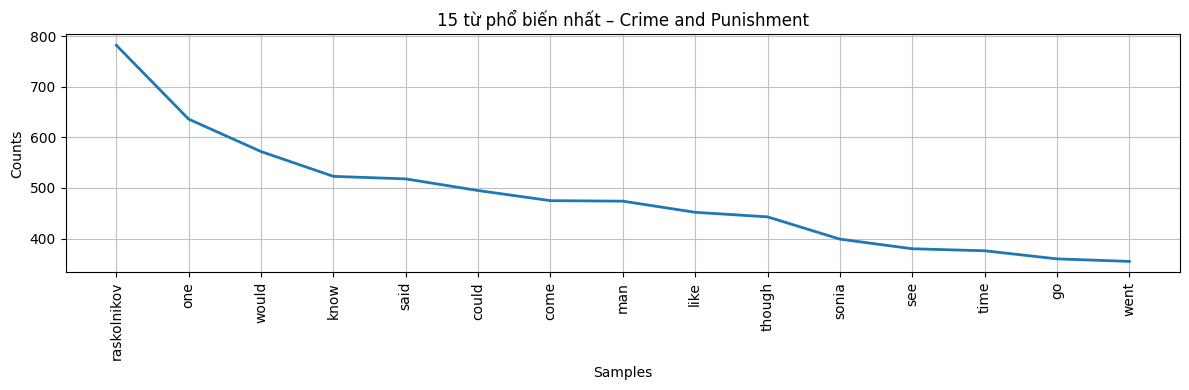

In [28]:
# Phân tích tần số văn bản trên mạng
web_sw = set(nltk.corpus.stopwords.words('english'))
web_filtered = [
    w.lower() for w in tokens
    if w.lower() not in web_sw
    and w.lower() not in punctuation
    and w.isalpha()
]
fd_web = nltk.FreqDist(web_filtered)
print('10 TỪ PHỔ BIẾN NHẤT TRONG VĂN BẢN TỪ MẠNG')
print(fd_web.most_common(10))

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
fd_web.plot(15, title='15 từ phổ biến nhất – Crime and Punishment',
            cumulative=False)
plt.tight_layout()
plt.show()

---
## Phần 7 – Rút trích văn bản từ trang HTML

In [30]:
from bs4 import BeautifulSoup

url_html = 'http://news.bbc.co.uk/2/hi/health/2284783.stm'
try:
    html = request.urlopen(url_html).read().decode('utf-8', errors='ignore')
    raw_html = BeautifulSoup(html, 'lxml').get_text()
    print(f'Tải trang HTML thành công! ({len(html):,} ký tự)')
except Exception as e:
    print(f'Không tải được trang: {e}')
    # Dùng văn bản mẫu
    raw_html = """
    Scientists have found that regular exercise can significantly reduce the risk
    of heart disease and improve overall health. The study, published in the medical
    journal, showed that people who exercise at least 30 minutes a day have better
    cardiovascular health and live longer lives. Researchers recommend daily physical
    activity for all age groups to maintain good health and prevent chronic diseases.
    The findings suggest that even moderate exercise can have profound benefits on
    mental health, reducing symptoms of depression and anxiety in patients.
    """
    print('Sử dụng văn bản mẫu về sức khỏe.')

# Tokenize văn bản HTML
tokens_html = nltk.word_tokenize(raw_html)
text_html   = nltk.Text(tokens_html)

print(f'\nSố token từ trang HTML: {len(tokens_html):,}')
print(f'50 ký tự đầu: {raw_html[:200].strip()}')

Tải trang HTML thành công! (37,306 ký tự)

Số token từ trang HTML: 753
50 ký tự đầu: BBC NEWS | Health | Blondes 'to die out in 200 years'




































NEWS
  SPORT
  WEATHER
  WORLD SERVICE

  A-Z INDEX 

  SEARCH


In [31]:
# Phân tích tần số văn bản HTML
html_filtered = [
    w.lower() for w in tokens_html
    if w.lower() not in web_sw
    and w.lower() not in punctuation
    and w.isalpha() and len(w) > 2
]
fd_html = nltk.FreqDist(html_filtered)
print('10 TỪ PHỔ BIẾN NHẤT TỪ TRANG HTML')
print(fd_html.most_common(10))

10 TỪ PHỔ BIẾN NHẤT TỪ TRANG HTML
[('blondes', 14), ('health', 10), ('news', 7), ('gene', 7), ('bbc', 6), ('die', 5), ('last', 4), ('blonde', 4), ('hair', 4), ('may', 4)]


---
## Phần 8 – Phân tích cảm xúc người dùng (Sentiment Analysis)

In [32]:
# Chuẩn bị dữ liệu movie_reviews
reviews = nltk.corpus.movie_reviews

# Tạo dataset: (nội dung review, nhãn)
documents = [
    (list(reviews.words(fileid)), category)
    for category in reviews.categories()
    for fileid in reviews.fileids(category)
]
random.shuffle(documents)

print(f'Tổng số review: {len(documents)}')
print(f'Số lớp: {reviews.categories()}')

# Xem ví dụ
print(f'\nNhãn review đầu tiên: "{documents[0][1]}"')
print(f'100 từ đầu: {" ".join(documents[0][0][:100])}')

Tổng số review: 2000
Số lớp: ['neg', 'pos']

Nhãn review đầu tiên: "neg"
100 từ đầu: if you ' re debating whether or not to see _breakfast_of_champions_ , ask yourself one simple question : do you want to see nick nolte in lingerie ? the only people who would get much enjoyment from alan rudolph ' s chaotic adaptation of the kurt vonnegut novel is the cross - section of the population with the unhealthy urge to see that unpleasant sight . everyone else -- and i ' m hoping that ' s most people -- would be wise to steer clear of this excrutiatingly unfunny mess . actually , though , the sight of nolte


In [33]:
# Tạo bảng tần số tất cả từ trong corpus
all_words    = nltk.FreqDist(w.lower() for w in reviews.words())
word_features = list(all_words)[:3000]  # Dùng 3000 từ phổ biến nhất

print(f'Số từ trong từ vựng: {len(all_words):,}')
print(f'Dùng {len(word_features):,} từ làm đặc trưng')

Số từ trong từ vựng: 39,768
Dùng 3,000 từ làm đặc trưng


In [34]:
# Hàm tạo đặc trưng cho mỗi document
def document_features(document, word_features):
    document_words = set(document)
    features = {}
    for word in word_features:
        features[f'{word}'] = (word in document_words)
    return features

# Tạo feature sets
featuresets = [
    (document_features(d, word_features), c)
    for (d, c) in documents
]
print(f'Tổng số feature sets: {len(featuresets)}')

Tổng số feature sets: 2000


In [35]:
# Chia train / test và huấn luyện Naive Bayes Classifier
train_set = featuresets[500:]   # 1500 mẫu train
test_set  = featuresets[:500]   # 500 mẫu test

print('Đang huấn luyện Naive Bayes Classifier...')
classifier = nltk.NaiveBayesClassifier.train(train_set)

accuracy_score = nltk.classify.accuracy(classifier, test_set)
print(f'\n Độ chính xác trên tập test: {accuracy_score:.2%}')

Đang huấn luyện Naive Bayes Classifier...

 Độ chính xác trên tập test: 82.00%


In [39]:
# Hiển thị 15 đặc trưng quan trọng nhất
print('15 ĐẶC TRƯNG QUAN TRỌNG NHẤT')
classifier.show_most_informative_features(15)

15 ĐẶC TRƯNG QUAN TRỌNG NHẤT
Most Informative Features
                  seagal = True              neg : pos    =     11.2 : 1.0
             outstanding = True              pos : neg    =     10.8 : 1.0
                   inept = True              neg : pos    =      8.3 : 1.0
              schumacher = True              neg : pos    =      7.8 : 1.0
                  alicia = True              neg : pos    =      7.2 : 1.0
                    lame = True              neg : pos    =      6.7 : 1.0
                  random = True              neg : pos    =      6.7 : 1.0
                  wasted = True              neg : pos    =      6.5 : 1.0
                 idiotic = True              neg : pos    =      6.2 : 1.0
             wonderfully = True              pos : neg    =      6.0 : 1.0
                   awful = True              neg : pos    =      6.0 : 1.0
                   jolie = True              neg : pos    =      5.8 : 1.0
             beautifully = True              

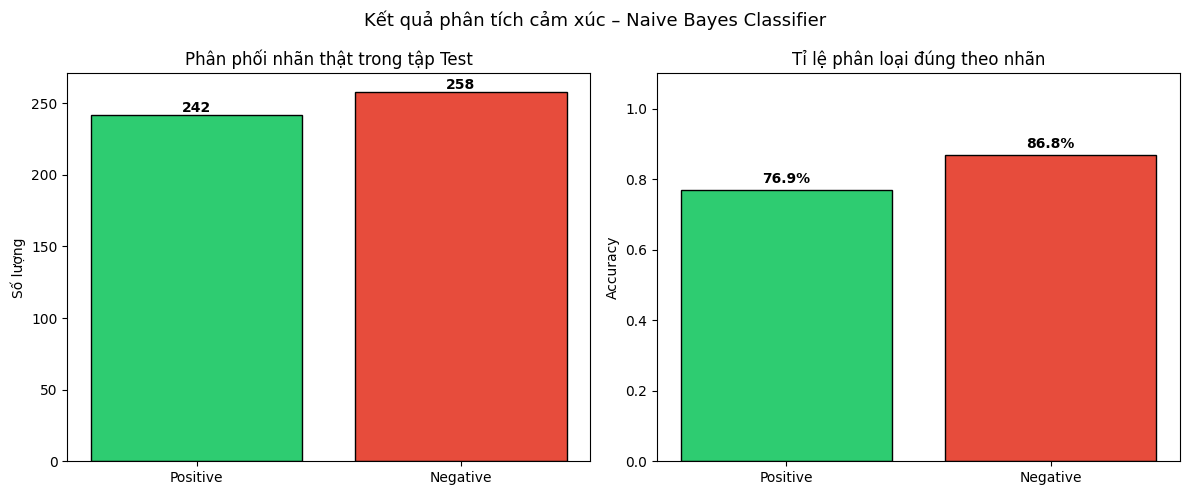


 Tổng kết:
   Positive phân loại đúng: 186/242 (76.9%)
   Negative phân loại đúng: 224/258 (86.8%)
   Accuracy tổng thể       : 82.00%


In [40]:
# Trực quan hóa phân phối nhãn trong tập test
import numpy as np

predictions = [classifier.classify(f) for (f, _) in test_set]
true_labels = [label for (_, label) in test_set]

pos_correct = sum(1 for p, t in zip(predictions, true_labels) if p == t == 'pos')
neg_correct = sum(1 for p, t in zip(predictions, true_labels) if p == t == 'neg')
pos_total   = sum(1 for t in true_labels if t == 'pos')
neg_total   = sum(1 for t in true_labels if t == 'neg')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Kết quả phân tích cảm xúc – Naive Bayes Classifier', fontsize=13)

# Phân phối nhãn thật
axes[0].bar(['Positive', 'Negative'], [pos_total, neg_total],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Phân phối nhãn thật trong tập Test')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate([pos_total, neg_total]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Tỉ lệ phân loại đúng
axes[1].bar(['Positive', 'Negative'],
            [pos_correct/pos_total, neg_correct/neg_total],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Tỉ lệ phân loại đúng theo nhãn')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate([pos_correct/pos_total, neg_correct/neg_total]):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n Tổng kết:')
print(f'   Positive phân loại đúng: {pos_correct}/{pos_total} ({pos_correct/pos_total:.1%})')
print(f'   Negative phân loại đúng: {neg_correct}/{neg_total} ({neg_correct/neg_total:.1%})')
print(f'   Accuracy tổng thể       : {accuracy_score:.2%}')

In [38]:
# Thử phân loại review mới
sample_reviews = [
    "This movie was absolutely wonderful and fantastic! Great performance by the actors.",
    "Terrible film. Boring plot, bad acting. Complete waste of time.",
    "The story was okay but the special effects were amazing and visually stunning."
]

print('=== THỬ PHÂN LOẠI REVIEW MỚI ===')
for review in sample_reviews:
    tokens_r = nltk.word_tokenize(review.lower())
    features = document_features(tokens_r, word_features)
    label    = classifier.classify(features)
    prob_dist = classifier.prob_classify(features)
    print(f'\n  Review : "{review[:60]}..."')
    print(f'  Kết quả: {label.upper()} (pos={prob_dist.prob("pos"):.2%}, neg={prob_dist.prob("neg"):.2%})')

=== THỬ PHÂN LOẠI REVIEW MỚI ===

  Review : "This movie was absolutely wonderful and fantastic! Great per..."
  Kết quả: NEG (pos=0.00%, neg=100.00%)

  Review : "Terrible film. Boring plot, bad acting. Complete waste of ti..."
  Kết quả: NEG (pos=0.00%, neg=100.00%)

  Review : "The story was okay but the special effects were amazing and ..."
  Kết quả: NEG (pos=0.00%, neg=100.00%)


---
## Phần 9 – Bài tập áp dụng

### Bài 1 – Liệt kê tên tất cả corpus trong NLTK

In [41]:
print('=== DANH SÁCH CÁC CORPUS NLTK ===')
corpus_list = [
    'gutenberg', 'brown', 'reuters', 'inaugural', 'webtext',
    'nps_chat', 'shakespeare', 'state_union', 'names',
    'stopwords', 'movie_reviews', 'wordnet'
]
for i, corpus in enumerate(corpus_list, 1):
    print(f'  {i:2}. {corpus}')
print(f'\nTổng số corpus phổ biến: {len(corpus_list)}')

=== DANH SÁCH CÁC CORPUS NLTK ===
   1. gutenberg
   2. brown
   3. reuters
   4. inaugural
   5. webtext
   6. nps_chat
   7. shakespeare
   8. state_union
   9. names
  10. stopwords
  11. movie_reviews
  12. wordnet

Tổng số corpus phổ biến: 12


### Bài 2 – Liệt kê stopwords theo nhiều ngôn ngữ

In [42]:
print('STOPWORDS THEO TỪNG NGÔN NGỮ')
languages = ['english', 'french', 'german', 'spanish', 'italian',
             'portuguese', 'dutch', 'russian', 'arabic', 'indonesian']

for lang in languages:
    try:
        sw_lang = nltk.corpus.stopwords.words(lang)
        print(f'  {lang:<12}: {len(sw_lang):>3} từ | Ví dụ: {sw_lang[:5]}')
    except Exception as e:
        print(f'  {lang:<12}: Không có dữ liệu')

=== STOPWORDS THEO TỪNG NGÔN NGỮ ===
  english     : 198 từ | Ví dụ: ['a', 'about', 'above', 'after', 'again']
  french      : 157 từ | Ví dụ: ['au', 'aux', 'avec', 'ce', 'ces']
  german      : 232 từ | Ví dụ: ['aber', 'alle', 'allem', 'allen', 'aller']
  spanish     : 313 từ | Ví dụ: ['de', 'la', 'que', 'el', 'en']
  italian     : 279 từ | Ví dụ: ['ad', 'al', 'allo', 'ai', 'agli']
  portuguese  : 207 từ | Ví dụ: ['a', 'à', 'ao', 'aos', 'aquela']
  dutch       : 101 từ | Ví dụ: ['de', 'en', 'van', 'ik', 'te']
  russian     : 151 từ | Ví dụ: ['и', 'в', 'во', 'не', 'что']
  arabic      : 754 từ | Ví dụ: ['إذ', 'إذا', 'إذما', 'إذن', 'أف']
  indonesian  : 758 từ | Ví dụ: ['ada', 'adalah', 'adanya', 'adapun', 'agak']


### Bài 3 – Kiểm tra xem một từ có phải là stopword không

In [43]:
def check_stopword(word, language='english'):
    """Kiểm tra một từ có phải là stopword của ngôn ngữ đã cho không"""
    sw_set = set(nltk.corpus.stopwords.words(language))
    is_sw  = word.lower() in sw_set
    status = '✅ LÀ stopword' if is_sw else '❌ KHÔNG phải stopword'
    print(f'  Từ "{word}" ({language}): {status}')
    return is_sw

print('=== KIỂM TRA STOPWORD ===')
test_words = [
    ('the',     'english'),
    ('Macbeth', 'english'),
    ('is',      'english'),
    ('le',      'french'),
    ('der',     'german'),
]
for word, lang in test_words:
    check_stopword(word, lang)

=== KIỂM TRA STOPWORD ===
  Từ "the" (english): ✅ LÀ stopword
  Từ "Macbeth" (english): ❌ KHÔNG phải stopword
  Từ "is" (english): ✅ LÀ stopword
  Từ "le" (french): ✅ LÀ stopword
  Từ "der" (german): ✅ LÀ stopword


### Bài 4 – Loại bỏ stopwords từ văn bản cho trước

In [46]:
def remove_stopwords(text_input, language='english'):
    """Loại bỏ stopwords và dấu câu từ văn bản"""
    sw_set   = set(nltk.corpus.stopwords.words(language))
    punc_set = set(string.punctuation)
    tokens   = nltk.word_tokenize(text_input.lower())
    filtered = [w for w in tokens if w not in sw_set and w not in punc_set]
    return filtered

sample_text = """
To be or not to be, that is the question. Whether it is nobler in the mind
to suffer the slings and arrows of outrageous fortune, or to take arms
against a sea of troubles and by opposing end them.
"""

print('VĂN BẢN GỐC')
print(sample_text.strip())

filtered_result = remove_stopwords(sample_text)
print(f'\n=== SAU KHI LOẠI STOPWORDS ({len(filtered_result)} từ còn lại) ===')
print(filtered_result)

VĂN BẢN GỐC
To be or not to be, that is the question. Whether it is nobler in the mind
to suffer the slings and arrows of outrageous fortune, or to take arms
against a sea of troubles and by opposing end them.

=== SAU KHI LOẠI STOPWORDS (15 từ còn lại) ===
['question', 'whether', 'nobler', 'mind', 'suffer', 'slings', 'arrows', 'outrageous', 'fortune', 'take', 'arms', 'sea', 'troubles', 'opposing', 'end']


### Bài 5 – Bỏ qua stopwords từ danh sách cho trước

In [47]:
def filter_custom_stopwords(word_list, custom_stopwords):
    """Lọc từ danh sách bằng custom stopwords"""
    custom_set = set(w.lower() for w in custom_stopwords)
    return [w for w in word_list if w.lower() not in custom_set]

# Danh sách từ mẫu
word_list_sample = ['Macbeth', 'the', 'king', 'is', 'dead', 'long', 'live', 'the', 'king']
custom_sw        = ['the', 'is', 'a', 'an', 'in', 'on', 'at']

print('DANH SÁCH GỐC')
print(word_list_sample)

print(f'\n=== SAU KHI LỌC CUSTOM STOPWORDS {custom_sw} ===')
print(filter_custom_stopwords(word_list_sample, custom_sw))

DANH SÁCH GỐC
['Macbeth', 'the', 'king', 'is', 'dead', 'long', 'live', 'the', 'king']

=== SAU KHI LỌC CUSTOM STOPWORDS ['the', 'is', 'a', 'an', 'in', 'on', 'at'] ===
['Macbeth', 'king', 'dead', 'long', 'live', 'king']


### Bài 6 – Tìm định nghĩa và ví dụ của một từ bằng WordNet

In [48]:
from nltk.corpus import wordnet

def get_word_info(word):
    """Tìm định nghĩa, ví dụ từ WordNet"""
    synsets = wordnet.synsets(word)
    if not synsets:
        print(f'Không tìm thấy thông tin cho từ "{word}"')
        return

    print(f'THÔNG TIN TỪ "{word.upper()}" (WordNet)')
    for i, syn in enumerate(synsets[:4], 1):
        print(f'\n  [{i}] Synset: {syn.name()}')
        print(f'      Từ loại : {syn.pos()}')
        print(f'      Định nghĩa: {syn.definition()}')
        if syn.examples():
            print(f'      Ví dụ  : {syn.examples()[0]}')

get_word_info('computer')
print('\n' + '='*60)
get_word_info('run')

THÔNG TIN TỪ "COMPUTER" (WordNet)

  [1] Synset: computer.n.01
      Từ loại : n
      Định nghĩa: a machine for performing calculations automatically

  [2] Synset: calculator.n.01
      Từ loại : n
      Định nghĩa: an expert at calculation (or at operating calculating machines)

THÔNG TIN TỪ "RUN" (WordNet)

  [1] Synset: run.n.01
      Từ loại : n
      Định nghĩa: a score in baseball made by a runner touching all four bases safely
      Ví dụ  : the Yankees scored 3 runs in the bottom of the 9th

  [2] Synset: test.n.05
      Từ loại : n
      Định nghĩa: the act of testing something
      Ví dụ  : in the experimental trials the amount of carbon was measured separately

  [3] Synset: footrace.n.01
      Từ loại : n
      Định nghĩa: a race run on foot
      Ví dụ  : she broke the record for the half-mile run

  [4] Synset: streak.n.01
      Từ loại : n
      Định nghĩa: an unbroken series of events
      Ví dụ  : had a streak of bad luck


### Bài 7 – Tìm từ đồng nghĩa và trái nghĩa

In [49]:
def get_synonyms_antonyms(word):
    """Tìm từ đồng nghĩa và trái nghĩa của một từ"""
    synonyms, antonyms = set(), set()

    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonyms.add(lemma.name().replace('_', ' '))
            if lemma.antonyms():
                antonyms.add(lemma.antonyms()[0].name().replace('_', ' '))

    synonyms.discard(word)  # Bỏ chính từ đó khỏi danh sách
    print(f'\n=== TỪ: "{word.upper()}" ===')
    print(f'  Đồng nghĩa ({len(synonyms)}): {sorted(synonyms)[:10]}')
    print(f'  Trái nghĩa ({len(antonyms)}): {sorted(antonyms)[:10]}')

test_words_wn = ['good', 'happy', 'fast', 'love', 'big']
for w in test_words_wn:
    get_synonyms_antonyms(w)


=== TỪ: "GOOD" ===
  Đồng nghĩa (36): ['adept', 'beneficial', 'commodity', 'dear', 'dependable', 'effective', 'estimable', 'expert', 'full', 'goodness']
  Trái nghĩa (5): ['bad', 'badness', 'evil', 'evilness', 'ill']

=== TỪ: "HAPPY" ===
  Đồng nghĩa (3): ['felicitous', 'glad', 'well-chosen']
  Trái nghĩa (1): ['unhappy']

=== TỪ: "FAST" ===
  Đồng nghĩa (16): ['debauched', 'degenerate', 'degraded', 'dissipated', 'dissolute', 'fasting', 'firm', 'flying', 'immobile', 'libertine']
  Trái nghĩa (1): ['slow']

=== TỪ: "LOVE" ===
  Đồng nghĩa (35): ['bang', 'be intimate', 'bed', 'beloved', 'bonk', 'dear', 'dearest', 'do it', 'eff', 'enjoy']
  Trái nghĩa (1): ['hate']

=== TỪ: "BIG" ===
  Đồng nghĩa (35): ['adult', 'bad', 'bighearted', 'boastful', 'boastfully', 'bounteous', 'bountiful', 'braggart', 'bragging', 'braggy']
  Trái nghĩa (2): ['little', 'small']


### Bài 8 – Xem bộ tag POS và sử dụng biểu thức chính quy

In [50]:
# Bảng tag POS phổ biến
pos_tags_info = {
    'NN' : 'Danh từ số ít (Noun, singular)',
    'NNS': 'Danh từ số nhiều (Noun, plural)',
    'NNP': 'Danh từ riêng số ít (Proper noun)',
    'VB' : 'Động từ dạng nguyên mẫu (Verb, base form)',
    'VBD': 'Động từ quá khứ (Verb, past tense)',
    'VBG': 'Động từ dạng -ing (Verb, gerund)',
    'JJ' : 'Tính từ (Adjective)',
    'JJR': 'Tính từ so sánh hơn (Adjective, comparative)',
    'JJS': 'Tính từ bậc cao nhất (Adjective, superlative)',
    'RB' : 'Trạng từ (Adverb)',
    'PRP': 'Đại từ nhân xưng (Personal pronoun)',
    'DT' : 'Mạo từ (Determiner)',
    'IN' : 'Giới từ / liên từ (Preposition / conjunction)',
    'CC' : 'Liên từ kết hợp (Coordinating conjunction)',
    'CD' : 'Số đếm (Cardinal number)',
}

print('=== BỘ TAG POS PHỔ BIẾN ===')
for tag, desc in pos_tags_info.items():
    print(f'  {tag:<6}: {desc}')

=== BỘ TAG POS PHỔ BIẾN ===
  NN    : Danh từ số ít (Noun, singular)
  NNS   : Danh từ số nhiều (Noun, plural)
  NNP   : Danh từ riêng số ít (Proper noun)
  VB    : Động từ dạng nguyên mẫu (Verb, base form)
  VBD   : Động từ quá khứ (Verb, past tense)
  VBG   : Động từ dạng -ing (Verb, gerund)
  JJ    : Tính từ (Adjective)
  JJR   : Tính từ so sánh hơn (Adjective, comparative)
  JJS   : Tính từ bậc cao nhất (Adjective, superlative)
  RB    : Trạng từ (Adverb)
  PRP   : Đại từ nhân xưng (Personal pronoun)
  DT    : Mạo từ (Determiner)
  IN    : Giới từ / liên từ (Preposition / conjunction)
  CC    : Liên từ kết hợp (Coordinating conjunction)
  CD    : Số đếm (Cardinal number)


In [54]:
import re
import nltk # Ensure nltk is imported

nltk.download('averaged_perceptron_tagger_eng', quiet=True) # Download the missing resource

# POS Tagging trên câu mẫu
sample_sentence = 'The quick brown fox jumps over the lazy dog near the river bank'
tokens_s = nltk.word_tokenize(sample_sentence)
pos_tags  = nltk.pos_tag(tokens_s)

print('POS TAGGING')
print(f'Câu: "{sample_sentence}"\n')
for word, tag in pos_tags:
    desc = pos_tags_info.get(tag, 'Khác')
    print(f'  {word:<12} \u2192 {tag:<6} ({desc})')

# Dùng biểu thức chính quy để trích xuất noun phrases
print('\n NOUN PHRASES (Biểu thức chính quy)')
grammar    = r'NP: {<DT>?<JJ>*<NN.*>+}';
cp         = nltk.RegexpParser(grammar)
tree       = cp.parse(pos_tags)
for subtree in tree.subtrees(filter=lambda t: t.label() == 'NP'):
    phrase = ' '.join(word for word, tag in subtree.leaves())
    print(f'  {phrase}')

POS TAGGING
Câu: "The quick brown fox jumps over the lazy dog near the river bank"

  The          → DT     (Mạo từ (Determiner))
  quick        → JJ     (Tính từ (Adjective))
  brown        → NN     (Danh từ số ít (Noun, singular))
  fox          → NN     (Danh từ số ít (Noun, singular))
  jumps        → VBZ    (Khác)
  over         → IN     (Giới từ / liên từ (Preposition / conjunction))
  the          → DT     (Mạo từ (Determiner))
  lazy         → JJ     (Tính từ (Adjective))
  dog          → NN     (Danh từ số ít (Noun, singular))
  near         → IN     (Giới từ / liên từ (Preposition / conjunction))
  the          → DT     (Mạo từ (Determiner))
  river        → NN     (Danh từ số ít (Noun, singular))
  bank         → NN     (Danh từ số ít (Noun, singular))

 NOUN PHRASES (Biểu thức chính quy)
  The quick brown fox
  the lazy dog
  the river bank


### Bài 9 – So sánh sự giống nhau của hai DANH TỪ

In [56]:
def compare_nouns_similarity(noun1, noun2):
    """So sánh sự giống nhau của hai danh từ bằng Wu-Palmer Similarity"""
    syns1 = wordnet.synsets(noun1, pos=wordnet.NOUN)
    syns2 = wordnet.synsets(noun2, pos=wordnet.NOUN)

    if not syns1 or not syns2:
        print(f'Không tìm thấy synset cho "{noun1}" hoặc "{noun2}"')
        return

    sim = syns1[0].wup_similarity(syns2[0])
    path_sim = syns1[0].path_similarity(syns2[0])

    print(f'  Danh từ 1: "{noun1}" → {syns1[0].name()}: {syns1[0].definition()}')
    print(f'  Danh từ 2: "{noun2}" → {syns2[0].name()}: {syns2[0].definition()}')
    print(f'  Wu-Palmer Similarity : {sim:.4f}' if sim else '  Wu-Palmer: Không tính được')
    print(f'  Path Similarity      : {path_sim:.4f}' if path_sim else '  Path Sim : Không tính được')

noun_pairs = [
    ('dog',  'cat'),
    ('car',  'bus'),
    ('apple','fruit'),
    ('bank', 'river'),
]

print('SO SÁNH SỰ GIỐNG NHAU CỦA CÁC CẶP DANH TỪ')
for n1, n2 in noun_pairs:
    print(f'\n--- "{n1}" vs "{n2}" ---')
    compare_nouns_similarity(n1, n2)

SO SÁNH SỰ GIỐNG NHAU CỦA CÁC CẶP DANH TỪ

--- "dog" vs "cat" ---
  Danh từ 1: "dog" → dog.n.01: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds
  Danh từ 2: "cat" → cat.n.01: feline mammal usually having thick soft fur and no ability to roar: domestic cats; wildcats
  Wu-Palmer Similarity : 0.8571
  Path Similarity      : 0.2000

--- "car" vs "bus" ---
  Danh từ 1: "car" → car.n.01: a motor vehicle with four wheels; usually propelled by an internal combustion engine
  Danh từ 2: "bus" → bus.n.01: a vehicle carrying many passengers; used for public transport
  Wu-Palmer Similarity : 0.6667
  Path Similarity      : 0.1250

--- "apple" vs "fruit" ---
  Danh từ 1: "apple" → apple.n.01: fruit with red or yellow or green skin and sweet to tart crisp whitish flesh
  Danh từ 2: "fruit" → fruit.n.01: the ripened reproductive body of a seed plant
  Wu-Palmer Similarity : 0.9000
  Path Similari

### Bài 10 – So sánh sự giống nhau của hai ĐỘNG TỪ

In [57]:
def compare_verbs_similarity(verb1, verb2):
    """So sánh sự giống nhau của hai động từ"""
    syns1 = wordnet.synsets(verb1, pos=wordnet.VERB)
    syns2 = wordnet.synsets(verb2, pos=wordnet.VERB)

    if not syns1 or not syns2:
        print(f'Không tìm thấy synset cho "{verb1}" hoặc "{verb2}"')
        return

    sim      = syns1[0].wup_similarity(syns2[0])
    path_sim = syns1[0].path_similarity(syns2[0])

    print(f'  Động từ 1: "{verb1}" → {syns1[0].name()}: {syns1[0].definition()}')
    print(f'  Động từ 2: "{verb2}" → {syns2[0].name()}: {syns2[0].definition()}')
    print(f'  Wu-Palmer Similarity : {sim:.4f}' if sim else '  Wu-Palmer: Không tính được')
    print(f'  Path Similarity      : {path_sim:.4f}' if path_sim else '  Path Sim : Không tính được')

verb_pairs = [
    ('run',  'walk'),
    ('eat',  'drink'),
    ('say',  'speak'),
    ('love', 'hate'),
]

print('SO SÁNH SỰ GIỐNG NHAU CỦA CÁC CẶP ĐỘNG TỪ')
for v1, v2 in verb_pairs:
    print(f'\n--- "{v1}" vs "{v2}" ---')
    compare_verbs_similarity(v1, v2)

SO SÁNH SỰ GIỐNG NHAU CỦA CÁC CẶP ĐỘNG TỪ

--- "run" vs "walk" ---
  Động từ 1: "run" → run.v.01: move fast by using one's feet, with one foot off the ground at any given time
  Động từ 2: "walk" → walk.v.01: use one's feet to advance; advance by steps
  Wu-Palmer Similarity : 0.2857
  Path Similarity      : 0.2500

--- "eat" vs "drink" ---
  Động từ 1: "eat" → eat.v.01: take in solid food
  Động từ 2: "drink" → drink.v.01: take in liquids
  Wu-Palmer Similarity : 0.3333
  Path Similarity      : 0.3333

--- "say" vs "speak" ---
  Động từ 1: "say" → state.v.01: express in words
  Động từ 2: "speak" → talk.v.02: express in speech
  Wu-Palmer Similarity : 0.2500
  Path Similarity      : 0.1429

--- "love" vs "hate" ---
  Động từ 1: "love" → love.v.01: have a great affection or liking for
  Động từ 2: "hate" → hate.v.01: dislike intensely; feel antipathy or aversion towards
  Wu-Palmer Similarity : 0.4000
  Path Similarity      : 0.2500


### Bài 11 – Số lượng tên nam / nữ trong corpus Names

In [58]:
# Corpus names có 2 file: male.txt và female.txt
male_names   = nltk.corpus.names.words('male.txt')
female_names = nltk.corpus.names.words('female.txt')

print('=== THỐNG KÊ CORPUS NAMES ===')
print(f'  Số tên NAM  : {len(male_names):,}')
print(f'  Số tên NỮ   : {len(female_names):,}')
print(f'  Tổng cộng   : {len(male_names) + len(female_names):,}')

print('\n=== 10 TÊN NAM ĐẦU TIÊN ===')
print(list(male_names[:10]))

print('\n 10 TÊN NỮ ĐẦU TIÊN')
print(list(female_names[:10]))

=== THỐNG KÊ CORPUS NAMES ===
  Số tên NAM  : 2,943
  Số tên NỮ   : 5,001
  Tổng cộng   : 7,944

=== 10 TÊN NAM ĐẦU TIÊN ===
['Aamir', 'Aaron', 'Abbey', 'Abbie', 'Abbot', 'Abbott', 'Abby', 'Abdel', 'Abdul', 'Abdulkarim']

 10 TÊN NỮ ĐẦU TIÊN
['Abagael', 'Abagail', 'Abbe', 'Abbey', 'Abbi', 'Abbie', 'Abby', 'Abigael', 'Abigail', 'Abigale']


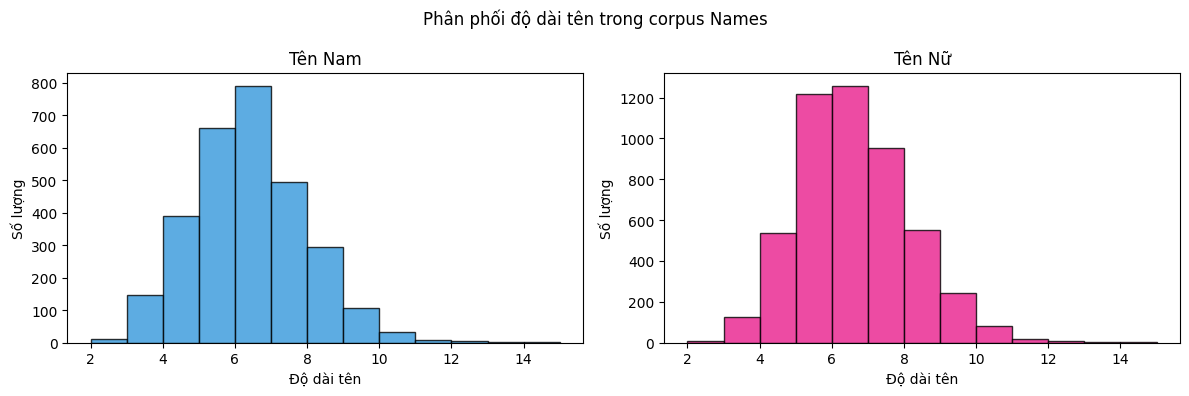

Độ dài trung bình tên Nam: 5.90 ký tự
Độ dài trung bình tên Nữ : 6.11 ký tự


In [59]:
# Biểu đồ phân phối độ dài tên
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phân phối độ dài tên trong corpus Names', fontsize=12)

male_lengths   = [len(n) for n in male_names]
female_lengths = [len(n) for n in female_names]

axes[0].hist(male_lengths,   bins=range(2, 16), color='#3498db',
             edgecolor='black', alpha=0.8)
axes[0].set_title('Tên Nam')
axes[0].set_xlabel('Độ dài tên')
axes[0].set_ylabel('Số lượng')

axes[1].hist(female_lengths, bins=range(2, 16), color='#e91e8c',
             edgecolor='black', alpha=0.8)
axes[1].set_title('Tên Nữ')
axes[1].set_xlabel('Độ dài tên')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

print(f'Độ dài trung bình tên Nam: {sum(male_lengths)/len(male_lengths):.2f} ký tự')
print(f'Độ dài trung bình tên Nữ : {sum(female_lengths)/len(female_lengths):.2f} ký tự')

### Bài 12 – In 15 tên ngẫu nhiên được gắn nhãn Nam / Nữ

In [61]:
# Tạo danh sách có nhãn và trộn ngẫu nhiên
labeled_names = ([(name, 'male')   for name in male_names] +
                 [(name, 'female') for name in female_names])
random.shuffle(labeled_names)

print('15 TÊN NGẪU NHIÊN CÓ GẮN NHÃN')
print(f'{"STT":<5} {"Tên":<20} {"Giới tính"}')
print('-' * 35)
for i, (name, gender) in enumerate(labeled_names[:15], 1):
    symbol = '♂ Nam' if gender == 'male' else '♀ Nữ'
    print(f'{i:<5} {name:<20} {symbol}')

15 TÊN NGẪU NHIÊN CÓ GẮN NHÃN
STT   Tên                  Giới tính
-----------------------------------
1     Rodolphe             ♂ Nam
2     Georgena             ♀ Nữ
3     Lenette              ♀ Nữ
4     Dwayne               ♂ Nam
5     Mirna                ♀ Nữ
6     Bertha               ♀ Nữ
7     Marci                ♀ Nữ
8     Dudley               ♂ Nam
9     Xylina               ♀ Nữ
10    Reggy                ♂ Nam
11    Eddy                 ♂ Nam
12    Francois             ♂ Nam
13    Noreen               ♀ Nữ
14    Nerta                ♀ Nữ
15    Esteban              ♂ Nam


### Bài 13 – Trích xuất ký tự cuối của tên và dự đoán giới tính

In [63]:
# Tạo mảng mới: (ký tự cuối, nhãn)
last_char_labeled = [(name[-1].lower(), gender) for (name, gender) in labeled_names]

print('15 MẪU ĐẦU: KÝ TỰ CUỐI VÀ NHÃN')
print(f'{"STT":<5} {"Tên gốc":<20} {"Ký tự cuối":<15} {"Nhãn"}')
print('-' * 50)
for i, ((name, gender), (last_c, _)) in enumerate(
        zip(labeled_names[:15], last_char_labeled[:15]), 1):
    print(f'{i:<5} {name:<20} {"{" + last_c + "}":<15} {gender}')

15 MẪU ĐẦU: KÝ TỰ CUỐI VÀ NHÃN
STT   Tên gốc              Ký tự cuối      Nhãn
--------------------------------------------------
1     Rodolphe             {e}             male
2     Georgena             {a}             female
3     Lenette              {e}             female
4     Dwayne               {e}             male
5     Mirna                {a}             female
6     Bertha               {a}             female
7     Marci                {i}             female
8     Dudley               {y}             male
9     Xylina               {a}             female
10    Reggy                {y}             male
11    Eddy                 {y}             male
12    Francois             {s}             male
13    Noreen               {n}             female
14    Nerta                {a}             female
15    Esteban              {n}             male


In [64]:
# Thống kê ký tự cuối theo giới tính
from collections import Counter

male_last_chars   = Counter(n[-1].lower() for n in male_names)
female_last_chars = Counter(n[-1].lower() for n in female_names)

print('KÝ TỰ CUỐI PHỔ BIẾN NHẤT THEO GIỚI TÍNH')
print(f'\nTên Nam  – 5 ký tự cuối phổ biến nhất:')
for char, count in male_last_chars.most_common(5):
    print(f'  "{char}": {count:,} lần ({count/len(male_names):.1%})')

print(f'\nTên Nữ   – 5 ký tự cuối phổ biến nhất:')
for char, count in female_last_chars.most_common(5):
    print(f'  "{char}": {count:,} lần ({count/len(female_names):.1%})')

KÝ TỰ CUỐI PHỔ BIẾN NHẤT THEO GIỚI TÍNH

Tên Nam  – 5 ký tự cuối phổ biến nhất:
  "n": 478 lần (16.2%)
  "e": 468 lần (15.9%)
  "y": 332 lần (11.3%)
  "s": 230 lần (7.8%)
  "d": 228 lần (7.7%)

Tên Nữ   – 5 ký tự cuối phổ biến nhất:
  "a": 1,773 lần (35.5%)
  "e": 1,432 lần (28.6%)
  "y": 461 lần (9.2%)
  "n": 386 lần (7.7%)
  "i": 317 lần (6.3%)


In [67]:
# Xây dựng classifier dự đoán giới tính từ ký tự cuối
def gender_features(name):
    """Trích xuất đặc trưng từ tên để dự đoán giới tính"""
    return {
        'last_letter'  : name[-1].lower(),
        'last2_letters': name[-2:].lower(),
        'first_letter' : name[0].lower(),
        'length'       : len(name),
        'ends_in_a'    : name[-1].lower() == 'a',
        'ends_in_e'    : name[-1].lower() == 'e',
        'ends_in_n'    : name[-1].lower() == 'n',
    }

# Chuẩn bị dữ liệu
name_featuresets = [(gender_features(n), g) for (n, g) in labeled_names]
train_names = name_featuresets[500:]
test_names  = name_featuresets[:500]

# Huấn luyện
gender_classifier = nltk.NaiveBayesClassifier.train(train_names)
acc = nltk.classify.accuracy(gender_classifier, test_names)
print(f'Độ chính xác dự đoán giới tính từ tên: {acc:.2%}')

# Thử dự đoán
print('\n THỬ DỰ ĐOÁN GIỚI TÍNH')
test_name_list = ['Anna', 'James', 'Maria', 'Robert', 'Sophie', 'John', 'Emma', 'David']
for name in test_name_list:
    pred = gender_classifier.classify(gender_features(name))
    icon = '♀ Nữ' if pred == 'female' else '♂ Nam'
    print(f'  {name:<10} → {icon}')

Độ chính xác dự đoán giới tính từ tên: 79.00%

 THỬ DỰ ĐOÁN GIỚI TÍNH
  Anna       → ♀ Nữ
  James      → ♂ Nam
  Maria      → ♀ Nữ
  Robert     → ♂ Nam
  Sophie     → ♀ Nữ
  John       → ♂ Nam
  Emma       → ♀ Nữ
  David      → ♂ Nam


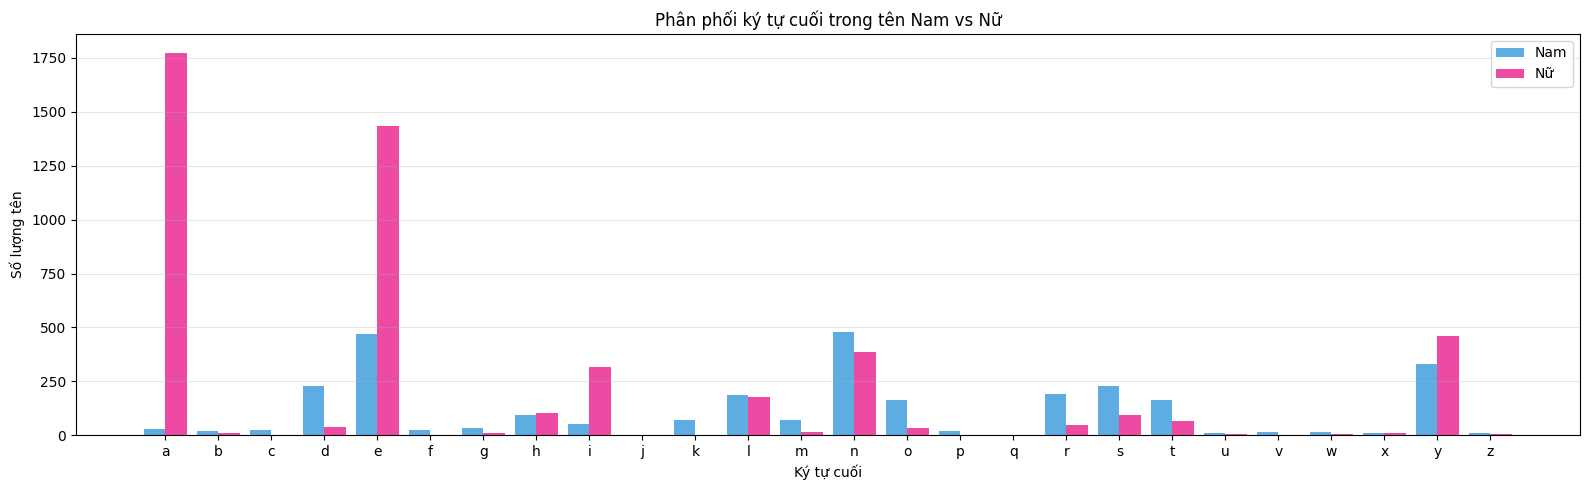

In [69]:
# Biểu đồ so sánh ký tự cuối giữa nam và nữ
import numpy as np

alphabet = list('abcdefghijklmnopqrstuvwxyz')
male_counts   = [male_last_chars.get(c, 0)   for c in alphabet]
female_counts = [female_last_chars.get(c, 0) for c in alphabet]

x = np.arange(len(alphabet))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, male_counts,   width, label='Nam',  color='#3498db', alpha=0.8)
ax.bar(x + width/2, female_counts, width, label='Nữ',   color='#e91e8c', alpha=0.8)
ax.set_title('Phân phối ký tự cuối trong tên Nam vs Nữ', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(alphabet)
ax.set_xlabel('Ký tự cuối')
ax.set_ylabel('Số lượng tên')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

NHẬN XÉT:
  - Tên Nữ thường kết thúc bằng chữ "a", "e", "y" nhiều hơn
  - Tên Nam thường kết thúc bằng chữ "n", "s", "r", "d" nhiều hơn
  → Ký tự cuối là đặc trưng quan trọng để phân biệt tên Nam/Nữ